# 01 EDA

Quick pass on class balance, missingness, segment risk, and train/test drift.


In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.fraud_detection.eda import (
    PLOT_COLORS,
    add_transaction_time_features,
    category_risk_table,
    compute_family_missingness,
    compute_psi_table,
    merge_identity_features,
    missingness_signal_table,
    quantile_fraud_table,
    reduce_memory_usage,
    set_plot_theme,
    standardize_identity_columns,
)

warnings.filterwarnings("ignore")
set_plot_theme()
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:,.4f}".format)

DATA_DIR = PROJECT_ROOT / "data" / "raw"
MAX_ROWS = None
IDENTITY_FEATURES = ["DeviceType", "DeviceInfo", "id_30", "id_31", "id_33"]
DRIFT_COLUMNS = [
    "TransactionID",
    "TransactionDT",
    "TransactionAmt",
    "ProductCD",
    "card4",
    "card6",
    "P_emaildomain",
    "R_emaildomain",
    "addr1",
    "dist1",
    "dist2",
    "C1",
    "D1",
    "D4",
    "D10",
    "D15",
    "M4",
    "M6",
]


In [2]:
# Load the full train tables and a smaller test slice for drift checks.
train_transaction = reduce_memory_usage(
    pd.read_csv(DATA_DIR / "train_transaction.csv", nrows=MAX_ROWS)
)
train_identity = standardize_identity_columns(
    reduce_memory_usage(pd.read_csv(DATA_DIR / "train_identity.csv", nrows=MAX_ROWS))
)

test_transaction = reduce_memory_usage(
    pd.read_csv(DATA_DIR / "test_transaction.csv", usecols=DRIFT_COLUMNS, nrows=MAX_ROWS)
)
test_identity = standardize_identity_columns(
    reduce_memory_usage(
        pd.read_csv(
            DATA_DIR / "test_identity.csv",
            usecols=["TransactionID", "DeviceType", "DeviceInfo", "id-30", "id-31", "id-33"],
            nrows=MAX_ROWS,
        )
    )
)

train_core_columns = [
    "TransactionID",
    "isFraud",
    "TransactionDT",
    "TransactionAmt",
    "ProductCD",
    "card4",
    "card6",
    "P_emaildomain",
    "R_emaildomain",
    "addr1",
    "addr2",
    "dist1",
    "dist2",
    "C1",
    "D1",
    "D4",
    "D10",
    "D15",
    "M4",
    "M6",
]
test_core_columns = [
    column
    for column in train_core_columns
    if column != "isFraud" and column in test_transaction.columns
]

train_core = merge_identity_features(
    train_transaction[train_core_columns],
    train_identity,
    IDENTITY_FEATURES,
)
train_core = add_transaction_time_features(train_core)
train_core["has_identity"] = train_core["TransactionID"].isin(train_identity["TransactionID"])

test_core = merge_identity_features(
    test_transaction[test_core_columns],
    test_identity,
    IDENTITY_FEATURES,
)
test_core = add_transaction_time_features(test_core)
test_core["has_identity"] = test_core["TransactionID"].isin(test_identity["TransactionID"])

inventory = pd.DataFrame(
    [
        ["train_transaction", len(train_transaction), train_transaction.shape[1], train_transaction.memory_usage(deep=True).sum() / 1024**2],
        ["train_identity", len(train_identity), train_identity.shape[1], train_identity.memory_usage(deep=True).sum() / 1024**2],
        ["test_transaction", len(test_transaction), len(pd.read_csv(DATA_DIR / "test_transaction.csv", nrows=0).columns), test_transaction.memory_usage(deep=True).sum() / 1024**2],
        ["test_identity", len(test_identity), len(pd.read_csv(DATA_DIR / "test_identity.csv", nrows=0).columns), test_identity.memory_usage(deep=True).sum() / 1024**2],
    ],
    columns=["table", "rows", "columns", "memory_mb"],
)

summary = pd.DataFrame(
    [
        ["fraud_rate", train_core["isFraud"].mean()],
        ["identity_coverage", train_core["has_identity"].mean()],
        ["fraud_rate_with_identity", train_core.loc[train_core["has_identity"], "isFraud"].mean()],
        ["fraud_rate_without_identity", train_core.loc[~train_core["has_identity"], "isFraud"].mean()],
    ],
    columns=["metric", "value"],
)

display(inventory.style.format({"rows": "{:,}", "columns": "{:,}", "memory_mb": "{:,.1f}"}).hide(axis="index"))
display(summary.style.format({"value": "{:.2%}"}).hide(axis="index"))


table,rows,columns,memory_mb
train_transaction,"590,540",394,"1,203.2"
train_identity,"144,233",41,129.9
test_transaction,"506,691",393,185.4
test_identity,"141,907",41,36.1


metric,value
fraud_rate,3.50%
identity_coverage,24.42%
fraud_rate_with_identity,7.85%
fraud_rate_without_identity,2.09%


## Overview


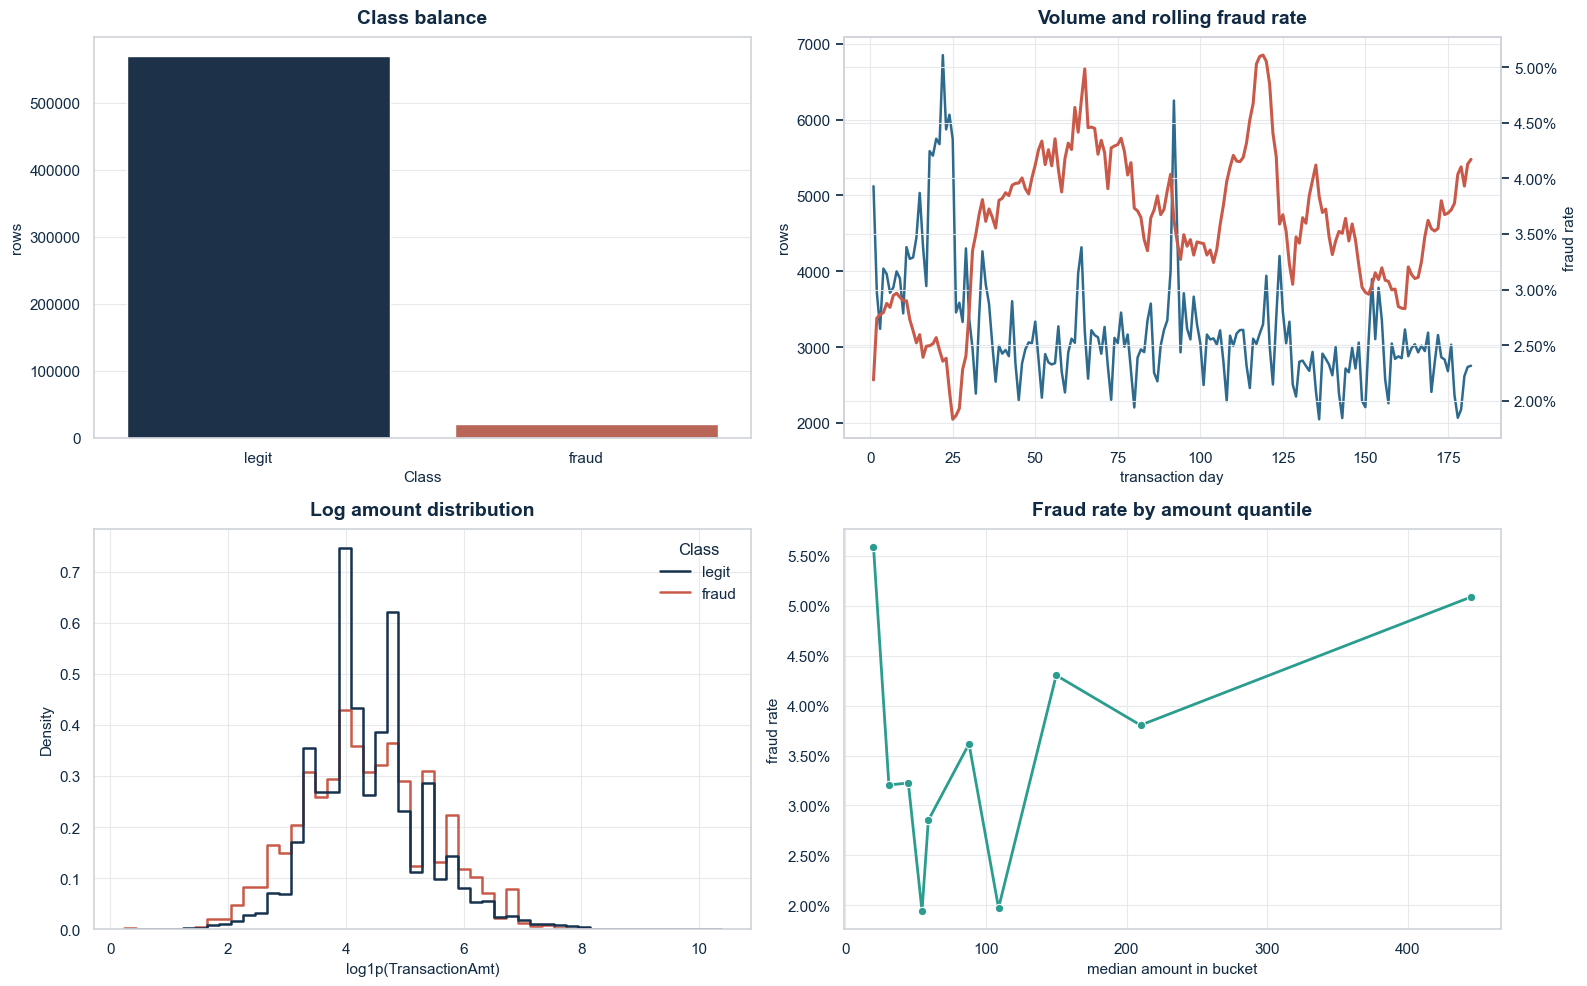

In [3]:
daily_profile = (
    train_core.groupby("TransactionDay", observed=False)
    .agg(transaction_count=("TransactionID", "size"), fraud_rate=("isFraud", "mean"))
    .reset_index()
)
daily_profile["fraud_rate_7d"] = daily_profile["fraud_rate"].rolling(7, min_periods=1).mean()

amount_profile = quantile_fraud_table(
    train_core,
    column="TransactionAmt",
    clip_upper_quantile=0.99,
)

amount_plot = train_core[["TransactionAmt", "isFraud"]].copy()
amount_plot["Class"] = amount_plot["isFraud"].map({0: "legit", 1: "fraud"})
amount_plot["LogTransactionAmt"] = np.log1p(amount_plot["TransactionAmt"])
amount_plot = amount_plot.sample(min(len(amount_plot), 200_000), random_state=42)

class_counts = (
    train_core["isFraud"]
    .map({0: "legit", 1: "fraud"})
    .value_counts()
    .rename_axis("Class")
    .reset_index(name="count")
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.barplot(data=class_counts, x="Class", y="count", palette=[PLOT_COLORS["navy"], PLOT_COLORS["coral"]], ax=axes[0, 0])
axes[0, 0].set_title("Class balance")
axes[0, 0].set_ylabel("rows")

volume_ax = axes[0, 1]
risk_ax = volume_ax.twinx()
volume_ax.plot(daily_profile["TransactionDay"], daily_profile["transaction_count"], color=PLOT_COLORS["blue"], linewidth=1.8)
risk_ax.plot(daily_profile["TransactionDay"], daily_profile["fraud_rate_7d"], color=PLOT_COLORS["coral"], linewidth=2.2)
volume_ax.set_title("Volume and rolling fraud rate")
volume_ax.set_xlabel("transaction day")
volume_ax.set_ylabel("rows")
risk_ax.set_ylabel("fraud rate")
risk_ax.yaxis.set_major_formatter(PercentFormatter(1))

sns.histplot(
    data=amount_plot,
    x="LogTransactionAmt",
    hue="Class",
    bins=50,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    linewidth=1.8,
    palette=[PLOT_COLORS["navy"], PLOT_COLORS["coral"]],
    ax=axes[1, 0],
)
axes[1, 0].set_title("Log amount distribution")
axes[1, 0].set_xlabel("log1p(TransactionAmt)")

sns.lineplot(
    data=amount_profile,
    x="median_value",
    y="fraud_rate",
    marker="o",
    linewidth=2,
    color=PLOT_COLORS["teal"],
    ax=axes[1, 1],
)
axes[1, 1].set_title("Fraud rate by amount quantile")
axes[1, 1].set_xlabel("median amount in bucket")
axes[1, 1].set_ylabel("fraud rate")
axes[1, 1].yaxis.set_major_formatter(PercentFormatter(1))

plt.tight_layout()
plt.show()


## Missingness


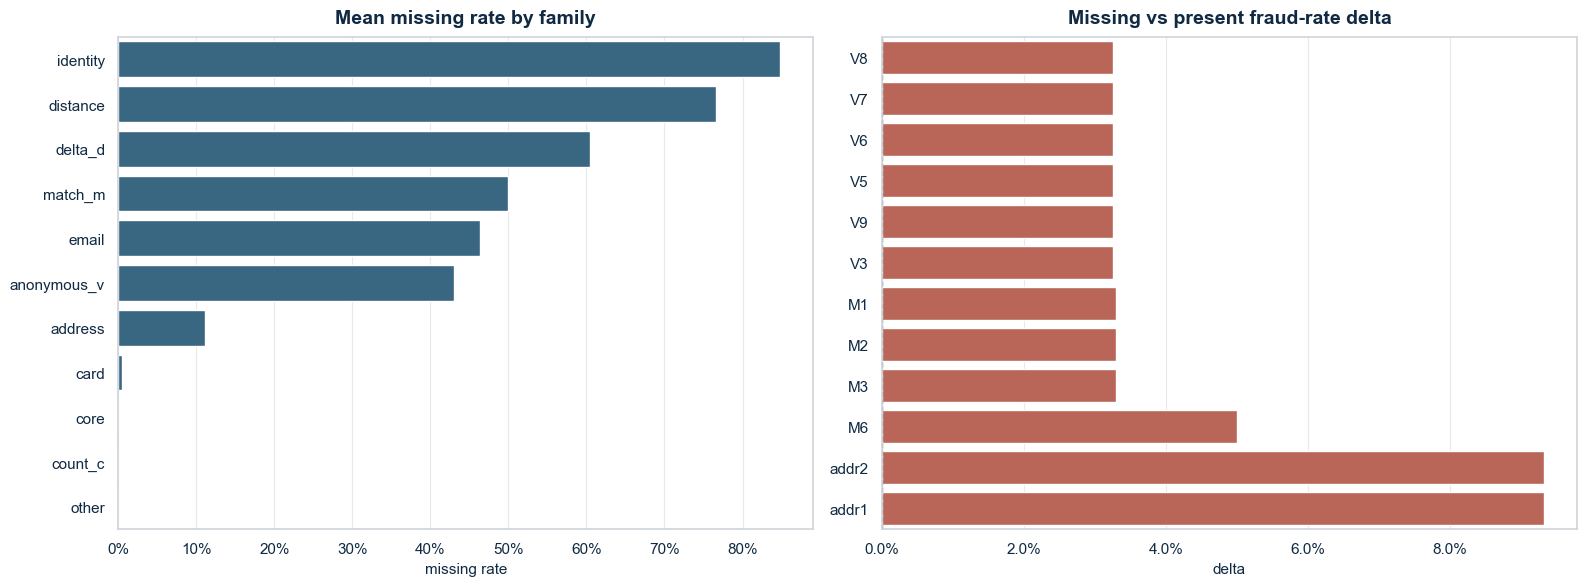

column,family,missing_count,present_count,fraud_rate_missing,fraud_rate_present,lift_vs_present
addr2,address,"65,706","524,834",11.78%,2.46%,+9.32%
addr1,address,"65,706","524,834",11.78%,2.46%,+9.32%
M6,match_m,"169,360","421,180",7.07%,2.06%,+5.00%
M1,match_m,"271,100","319,440",5.28%,1.99%,+3.30%
M2,match_m,"271,100","319,440",5.28%,1.99%,+3.30%
M3,match_m,"271,100","319,440",5.28%,1.99%,+3.30%
V8,anonymous_v,"279,287","311,253",5.21%,1.96%,+3.25%
V7,anonymous_v,"279,287","311,253",5.21%,1.96%,+3.25%
V6,anonymous_v,"279,287","311,253",5.21%,1.96%,+3.25%
V5,anonymous_v,"279,287","311,253",5.21%,1.96%,+3.25%


In [4]:
missingness_profile = compute_family_missingness(train_transaction, train_identity)
family_missingness = (
    missingness_profile.groupby("family", observed=False)
    .agg(mean_missing_rate=("missing_rate", "mean"), feature_count=("column", "size"))
    .reset_index()
    .sort_values("mean_missing_rate", ascending=False)
)
missing_signal = missingness_signal_table(train_transaction, min_support=5_000)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=family_missingness,
    x="mean_missing_rate",
    y="family",
    color=PLOT_COLORS["blue"],
    ax=axes[0],
)
axes[0].set_title("Mean missing rate by family")
axes[0].xaxis.set_major_formatter(PercentFormatter(1))
axes[0].set_xlabel("missing rate")
axes[0].set_ylabel("")

top_missing_lift = missing_signal.head(12).sort_values("lift_vs_present")
sns.barplot(
    data=top_missing_lift,
    x="lift_vs_present",
    y="column",
    color=PLOT_COLORS["coral"],
    ax=axes[1],
)
axes[1].axvline(0, linestyle="--", color=PLOT_COLORS["muted"], linewidth=1)
axes[1].set_title("Missing vs present fraud-rate delta")
axes[1].xaxis.set_major_formatter(PercentFormatter(1))
axes[1].set_xlabel("delta")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

display(
    missing_signal.head(12).style.format(
        {
            "missing_count": "{:,}",
            "present_count": "{:,}",
            "fraud_rate_missing": "{:.2%}",
            "fraud_rate_present": "{:.2%}",
            "lift_vs_present": "{:+.2%}",
        }
    ).hide(axis="index")
)


## Segment Risk


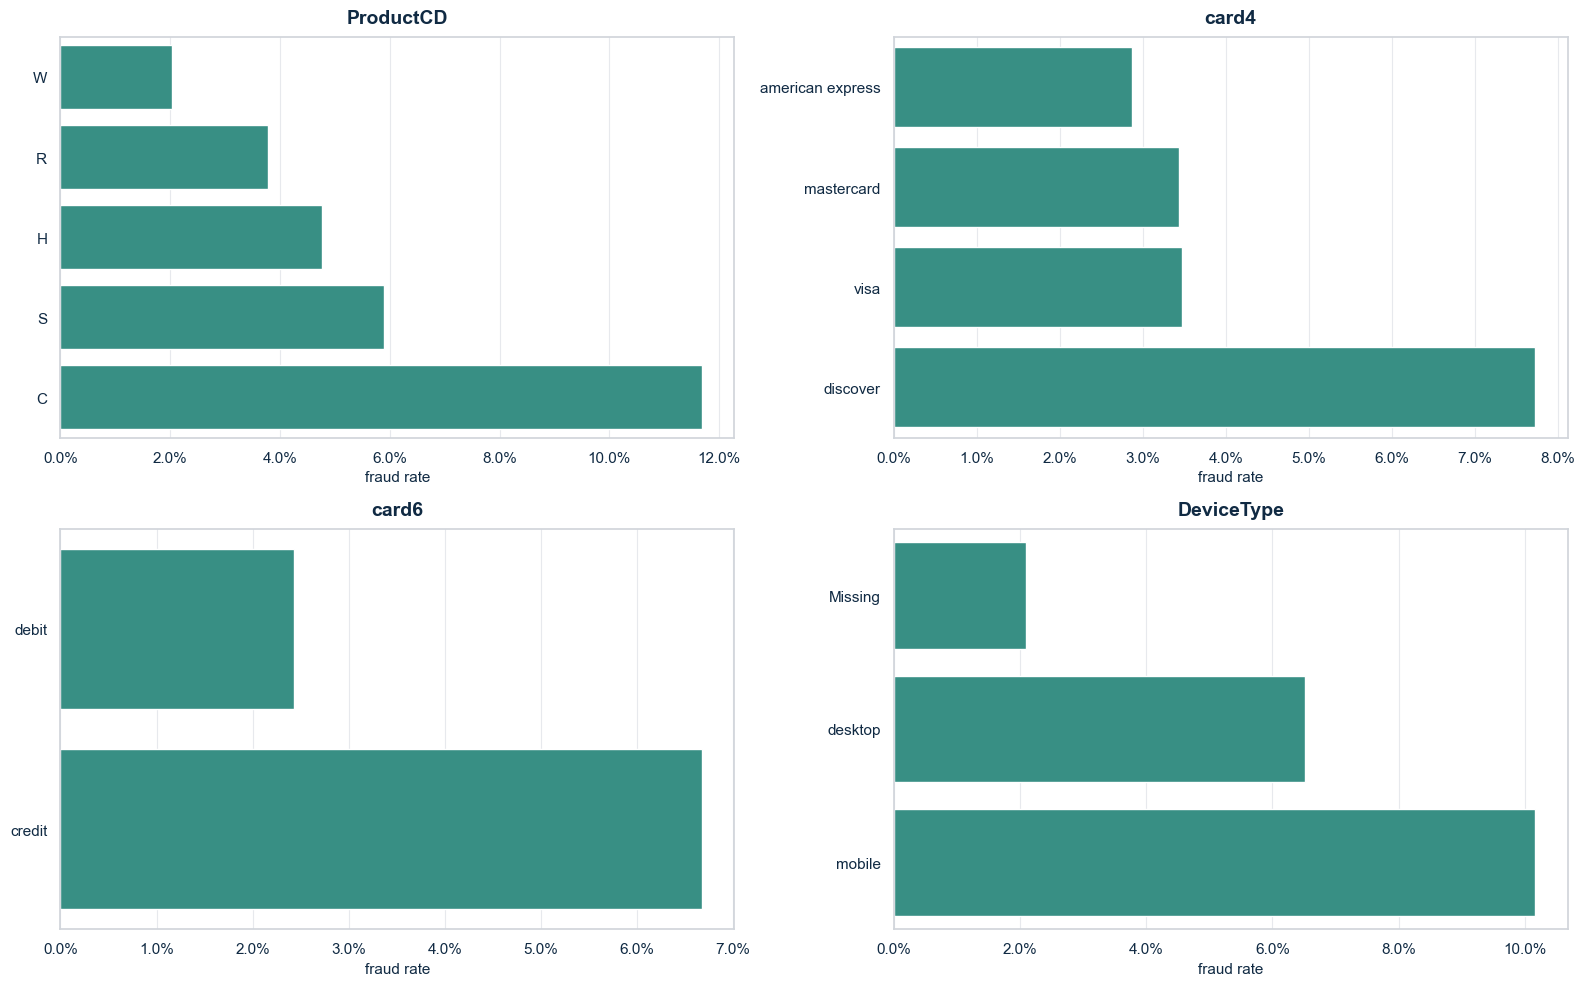

P_emaildomain,fraud_rate,count,share,lift_vs_base
outlook.com,9.46%,"5,096",0.86%,+5.96%
hotmail.com,5.30%,"45,250",7.66%,+1.80%
gmail.com,4.35%,"228,355",38.67%,+0.86%
icloud.com,3.14%,"6,267",1.06%,-0.36%
comcast.net,3.12%,"7,888",1.34%,-0.38%
Missing,2.95%,"94,456",15.99%,-0.55%
anonymous.com,2.32%,"36,998",6.27%,-1.18%
yahoo.com,2.28%,"100,934",17.09%,-1.22%
aol.com,2.18%,"28,289",4.79%,-1.32%


id_31,fraud_rate,count,share,lift_vs_base
chrome generic,16.81%,"4,778",0.81%,+13.31%
chrome 64.0 for android,15.89%,"3,473",0.59%,+12.40%
chrome 65.0 for android,14.72%,"3,336",0.56%,+11.22%
chrome 66.0 for android,12.98%,"2,349",0.40%,+9.49%
chrome 63.0 for android,11.25%,"5,806",0.98%,+7.75%
mobile safari generic,9.99%,"11,474",1.94%,+6.49%
chrome 65.0,9.88%,"6,871",1.16%,+6.38%
chrome 66.0,9.33%,"4,264",0.72%,+5.83%
chrome 64.0,9.16%,"6,711",1.14%,+5.67%
chrome 62.0 for android,7.68%,"2,097",0.36%,+4.18%


In [5]:
category_specs = [
    ("ProductCD", 5_000),
    ("card4", 5_000),
    ("card6", 5_000),
    ("DeviceType", 5_000),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, (column, min_count) in zip(axes.flatten(), category_specs):
    summary = category_risk_table(train_core, column, min_count=min_count, top_n=8).sort_values("fraud_rate")
    sns.barplot(data=summary, x="fraud_rate", y=column, color=PLOT_COLORS["teal"], ax=ax)
    ax.set_title(column)
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.set_xlabel("fraud rate")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

email_risk = category_risk_table(train_core, "P_emaildomain", min_count=5_000, top_n=10)
browser_risk = category_risk_table(train_core, "id_31", min_count=2_000, top_n=12)

display(email_risk.style.format({"fraud_rate": "{:.2%}", "share": "{:.2%}", "count": "{:,}", "lift_vs_base": "{:+.2%}"}).hide(axis="index"))
display(browser_risk.style.format({"fraud_rate": "{:.2%}", "share": "{:.2%}", "count": "{:,}", "lift_vs_base": "{:+.2%}"}).hide(axis="index"))


## Drift Check


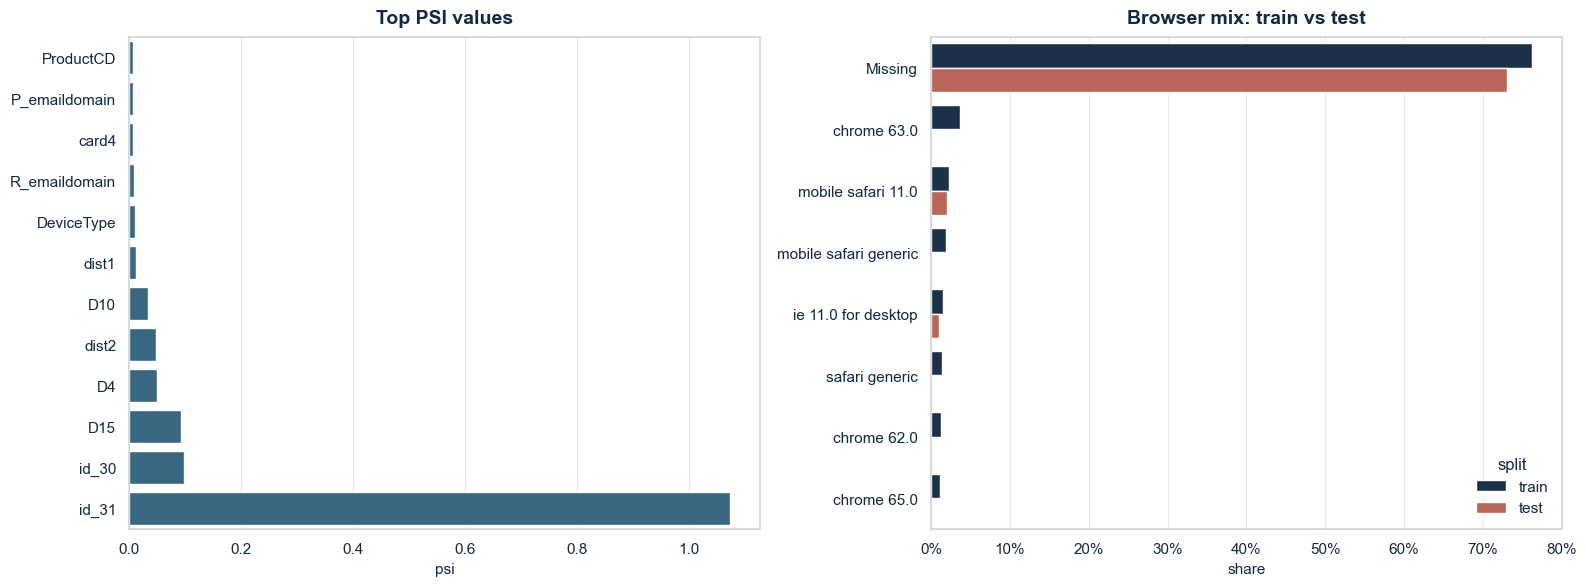

column,family,psi,drift_level
id_31,identity,1.074,high
id_30,identity,0.098,mild
D15,delta_d,0.093,mild
D4,delta_d,0.050,mild
dist2,distance,0.048,mild
D10,delta_d,0.033,mild
dist1,distance,0.011,stable
DeviceType,delta_d,0.009,stable
R_emaildomain,email,0.009,stable
card4,card,0.007,stable


In [6]:
categorical_drift_columns = [
    "ProductCD",
    "card4",
    "card6",
    "P_emaildomain",
    "R_emaildomain",
    "M4",
    "M6",
    "DeviceType",
    "id_30",
    "id_31",
]
drift_columns = [
    "TransactionAmt",
    "addr1",
    "dist1",
    "dist2",
    "C1",
    "D1",
    "D4",
    "D10",
    "D15",
    *categorical_drift_columns,
]

psi_table = compute_psi_table(
    train_core,
    test_core,
    columns=drift_columns,
    categorical_columns=categorical_drift_columns,
)

browser_train = train_core["id_31"].fillna("Missing").value_counts(normalize=True)
browser_test = test_core["id_31"].fillna("Missing").value_counts(normalize=True)
top_browsers = browser_train.head(8).index
browser_compare = pd.concat(
    [
        pd.DataFrame({"id_31": top_browsers, "share": browser_train.reindex(top_browsers, fill_value=0).values, "split": "train"}),
        pd.DataFrame({"id_31": top_browsers, "share": browser_test.reindex(top_browsers, fill_value=0).values, "split": "test"}),
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=psi_table.head(12).sort_values("psi"), x="psi", y="column", color=PLOT_COLORS["blue"], ax=axes[0])
axes[0].set_title("Top PSI values")
axes[0].set_xlabel("psi")
axes[0].set_ylabel("")

sns.barplot(data=browser_compare, x="share", y="id_31", hue="split", palette=[PLOT_COLORS["navy"], PLOT_COLORS["coral"]], ax=axes[1])
axes[1].set_title("Browser mix: train vs test")
axes[1].xaxis.set_major_formatter(PercentFormatter(1))
axes[1].set_xlabel("share")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

display(psi_table.style.format({"psi": "{:.3f}"}).hide(axis="index"))
